# Sieci Tensorowe w Fizyce Złożonych Układów Kwantowych
Eksploracyjny Notatnik Badawczy

Niniejszy notatnik stanowi rygorystyczne przejście od klasycznej mechaniki statystycznej (stany termiczne) do w pełni kwantowych zjawisk wielociałowych (kwantowe przejścia fazowe, splątanie) oraz symulacji otwartych układów kwantowych (dekohorencja w komputerach kwantowych).

Notatnik jest podzielony na cztery główne eksperymenty:

Ręczna konstrukcja MPO dla klasycznego stanu termicznego (Odtworzenie Przykładu 5.1 z M. Collura).

Kwantowy Hamiltonian jako MPO (Ręczne budowanie Hamiltoniana Isinga w poprzecznym polu vs wbudowane metody quimb).

Kwantowe Przejście Fazowe i Algorytm DMRG (Zrozumienie fizyki poprzez Entropię Splątania).

Wstęp do Równania Lindblada i Stanów Mieszanych (MPDO w symulacji komputerów kwantowych).

In [54]:
import numpy as np
import quimb as qu
import quimb.tensor as qtn
import matplotlib.pyplot as plt
import scipy.linalg as sla
from scipy.special import erfinv

# Ustawienia estetyczne wykresów i precyzji numerycznej
plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=4, suppress=True, linewidth=120)

# Fundamentalne macierze Pauliego
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# Eksperyment 1: Dokładne MPO dla klasycznych stanów termicznych
Zgodnie z Przykładem 5.1 (M. Collura, Tensor Network Techniques for Quantum Computation), rozważmy klasyczny ferromagnetyczny model Isinga w jednym wymiarze z jednorodnym polem magnetycznym $h$. Hamiltonian wyraża się wzorem:$$\hat{H} = -J \sum_{j} \hat{Z}_j \hat{Z}_{j+1} - h \sum_{j} \hat{Z}_j \equiv \hat{H}_J + \hat{H}_h$$Ponieważ operatory $\hat{H}_J$ i $\hat{H}_h$ komutują (zawierają tylko macierze $\hat{Z}$), operator gęstości termicznej $\exp(-\beta \hat{H})$ można zapisać jako dokładny iloczyn tensorowy (MPO) o skończonym wymiarze wiązania $\chi = 2$.Zbudujemy teraz ręcznie lokalne tensory $\hat{w}_j$ zdefiniowane w równaniu (5.14) i (5.15) i udowodnimy, że ich kontrakcja reprodukuje klasyczną macierz transferu $\tau$ z równania (5.16).Wykorzystamy do tego funkcję numpy.einsum, która jest niezwykle wydajnym narzędziem do manualnej kontrakcji tensorów opartym na konwencji sumacyjnej Einsteina.

In [5]:
def collura_thermal_mpo(beta, J, h):
    """
    Ręczna budowa lokalnego tensora MPO dla klasycznego modelu Isinga (Równanie 5.14 i 5.15).
    Zwraca krotkę (w1, w_bulk, wn) reprezentującą tensory brzegowe i bulkowe.
    Wymiary to (wirtualny_lewy, wirtualny_prawy, fizyczny_out, fizyczny_in).
    """
    # Macierze bramek (pomocnicze do budowy tensora)
    w_bulk = np.zeros((2, 2, 2, 2), dtype=complex)
    
    # Podstawiamy operatory zgodnie z macierzą 2x2 z równania (5.14)
    w_bulk[0, 0] = np.cosh(beta * J) * I
    w_bulk[0, 1] = np.cosh(beta * J) * Z
    w_bulk[1, 0] = np.sinh(beta * J) * Z
    w_bulk[1, 1] = np.sinh(beta * J) * I
    
    # Dodajemy wpływ pola magnetycznego H_h z równania (5.11)
    # Pole magnetyczne działa lokalnie: exp(\beta h Z) = cosh(\beta h)I + sinh(\beta h)Z
    M_h = np.cosh(beta * h) * I + np.sinh(beta * h) * Z
    
    # Aplikujemy pole magnetyczne do fizycznych nóg tensora w_bulk używając einsum.
    # Wzór: W_nowe^{v_L, v_R, p_{out}, p_{in}} = \sum_{k} W^{v_L, v_R, p_{out}, k} * M_h^{k, p_{in}}
    w_bulk_full = np.einsum('abcd,de->abce', w_bulk, M_h)
    
    # Tensory brzegowe (Równanie 5.15)
    w1 = w_bulk_full[0:1, :, :, :]  # Pierwszy wiersz
    wn = w_bulk_full[:, 0:1, :, :]  # Pierwsza kolumna
    
    return w1, w_bulk_full, wn

# Parametry fizyczne
beta = 1.0  # Odwrotność temperatury 1/(kT)
J = 1.0     # Całka wymiany
h = 0.5     # Pole magnetyczne

w1, w_bulk, wn = collura_thermal_mpo(beta, J, h)
print(f"Kształt tensora bulk (w_bulk): {w_bulk.shape} -> (vL, vR, pOut, pIn)")

# --- WERYFIKACJA FIZYCZNA: KLASYCZNA MACIERZ TRANSFERU ---
# Zgodnie z Collurą, ślad po indeksach fizycznych każdego węzła 
# (zamknięcie pętli dla każdej cząstki) redukuje MPO do klasycznej macierzy transferu (Eq. 5.16).
# Ślad fizyczny oznacza, że pOut == pIn, czyli sumujemy po c w 'abcc'.
tau_manual = np.einsum('abcc->ab', w_bulk).real

print("\nWyliczona ręcznie macierz transferu (Ślad fizyczny z w_bulk):")
print(tau_manual)

# Zbudujmy macierz tau bezpośrednio ze wzoru analitycznego Collury (5.16) dla porównania:
tau_analytic = 2 * np.array([
    [np.cosh(beta*J)*np.cosh(beta*h), np.cosh(beta*J)*np.sinh(beta*h)],
    [np.sinh(beta*J)*np.sinh(beta*h), np.sinh(beta*J)*np.cosh(beta*h)]
])

print("\nMacierz transferu ze wzoru (5.16) z książki Collury:")
print(tau_analytic)

assert np.allclose(tau_manual, tau_analytic)
print("\n Ręczna konstrukcja MPO za pomocą numpy.einsum idealnie odtwarza fizykę termiczną!")

Kształt tensora bulk (w_bulk): (2, 2, 2, 2) -> (vL, vR, pOut, pIn)

Wyliczona ręcznie macierz transferu (Ślad fizyczny z w_bulk):
[[3.48   1.6082]
 [1.2248 2.6504]]

Macierz transferu ze wzoru (5.16) z książki Collury:
[[3.48   1.6082]
 [1.2248 2.6504]]

 Ręczna konstrukcja MPO za pomocą numpy.einsum idealnie odtwarza fizykę termiczną!


Poprzez sprowadzenie sieci tensorowej MPO do klasycznej macierzy transferu $\tau$, funkcja podziału całego układu (Partition Function $\mathcal{Z}$) dla nieskończonego łańcucha zależy wyłącznie od największej wartości własnej tej macierzy. Jest to fundament przejścia między mechaniką statystyczną w $D$ wymiarach, a mechaniką kwantową w $D-1$ wymiarach.

# Eksperyment 2: Wejście w pełni Kwantowy Świat
Model klasyczny, choć piękny dydaktycznie, ma trywialną strukturę komutacyjną. W prawdziwej fizyce materii skondensowanej operatory nie komutują. Rozważmy flagowy układ: Jednowymiarowy Kwantowy Model Isinga w Polu Poprzecznym (TFIM):$$\hat{H} = -J \sum_{i=1}^{N-1} \hat{Z}_i \hat{Z}_{i+1} - g \sum_{i=1}^{N} \hat{X}_i$$Pole $g$ w osi $X$ indukuje kwantowe fluktuacje, które starają się zniszczyć porządek ferromagnetyczny narzucany przez oddziaływanie $J$ w osi $Z$. Ponieważ $[\hat{Z}_i \hat{Z}_{i+1}, \hat{X}_i] \neq 0$, nie możemy już w trywialny sposób napisać dokładnego MPO dla operatora gęstości $e^{-\beta \hat{H}}$. Możemy jednak zapisać samo $\hat{H}$ w postaci precyzyjnego MPO o wymiarze wiązania $D=3$.Najpierw zrobimy to "od zera" za pomocą maszyny stanów (automatu skończonego), a następnie porównamy wynik z biblioteką quimb.

In [25]:
def manual_quantum_ising_mpo(N, J, g):
    """
    Ręcznie buduje pełny macierzowy operator Hamiltoniana (MPO) dla kwantowego modelu TFIM.
    Stan wirtualny to automat o 3 stanach:
    0: Czekam na ułożenie par, mogę położyć pole g*X.
    1: Położyłem Z, czekam na drugie Z aby zamknąć parę oddziaływania J.
    2: Para zamknięta, przekazuję tożsamość I do końca łańcucha.
    """
    # Tensor W ma wymiar (3, 3, 2, 2)
    W = np.zeros((3, 3, 2, 2), dtype=complex)
    
    W[0, 0] = I
    W[0, 1] = -J * Z
    W[0, 2] = -g * X
    W[1, 2] = Z
    W[2, 2] = I
    
    # Tworzenie kompletnego MPO w bibliotece quimb z naszego ręcznego tensora
    tensors = []
    for i in range(N):
        if i == 0:
            # Pierwszy tensor: startujemy ze stanu 0 (pierwszy wiersz)
            T = W[0:1, :, :, :]
        elif i == N - 1:
            # Ostatni tensor: musimy skończyć w stanie 2 (ostatnia kolumna)
            T = W[:, 2:3, :, :]
        else:
            T = W
        tensors.append(T)
        
    return tensors

N = 8
J_val = 1.0
g_val = 0.5

# Zbudowanie ręcznego Hamiltoniana MPO
manual_mpo_tensors = manual_quantum_ising_mpo(N, J_val, g_val)
manual_mpo = qtn.MatrixProductOperator(manual_mpo_tensors, shape='lrud')

# Zbudowanie Hamiltoniana bezpośrednio za pomocą generatorów Quimb
# UWAGA: w Quimb hamiltonian Isinga domyślnie używa spinów 1/2 zamiast macierzy Pauliego. 
# Aby macierze były równe Pauli, skalujemy współczynniki: S_z = 1/2 Z -> J * 4, h * 2.
quimb_mpo = qtn.MPO_ham_ising(L=N, j=4.0*J_val, bx=2.0*g_val)

# Przekształcamy oba MPO do gęstej macierzy (pełna przestrzeń 2^N x 2^N = 256x256)
H_manual_dense = manual_mpo.to_dense()
H_quimb_dense = quimb_mpo.to_dense()

# Rozwiązujemy zagadnienie własne dla stanu podstawowego (E0)
E0_manual = sla.eigvalsh(H_manual_dense)
E0_quimb = sla.eigvalsh(H_quimb_dense)

print(f"Energia stanu podstawowego (Ręczne MPO): {E0_manual[0]}")
print(f"Energia stanu podstawowego (Quimb MPO):  {E0_quimb[0]}")
assert np.isclose(E0_manual, E0_quimb).all()
print(np.isclose(E0_manual, E0_quimb).all())

Energia stanu podstawowego (Ręczne MPO): -7.640592553590074
Energia stanu podstawowego (Quimb MPO):  -7.640592553590101
True


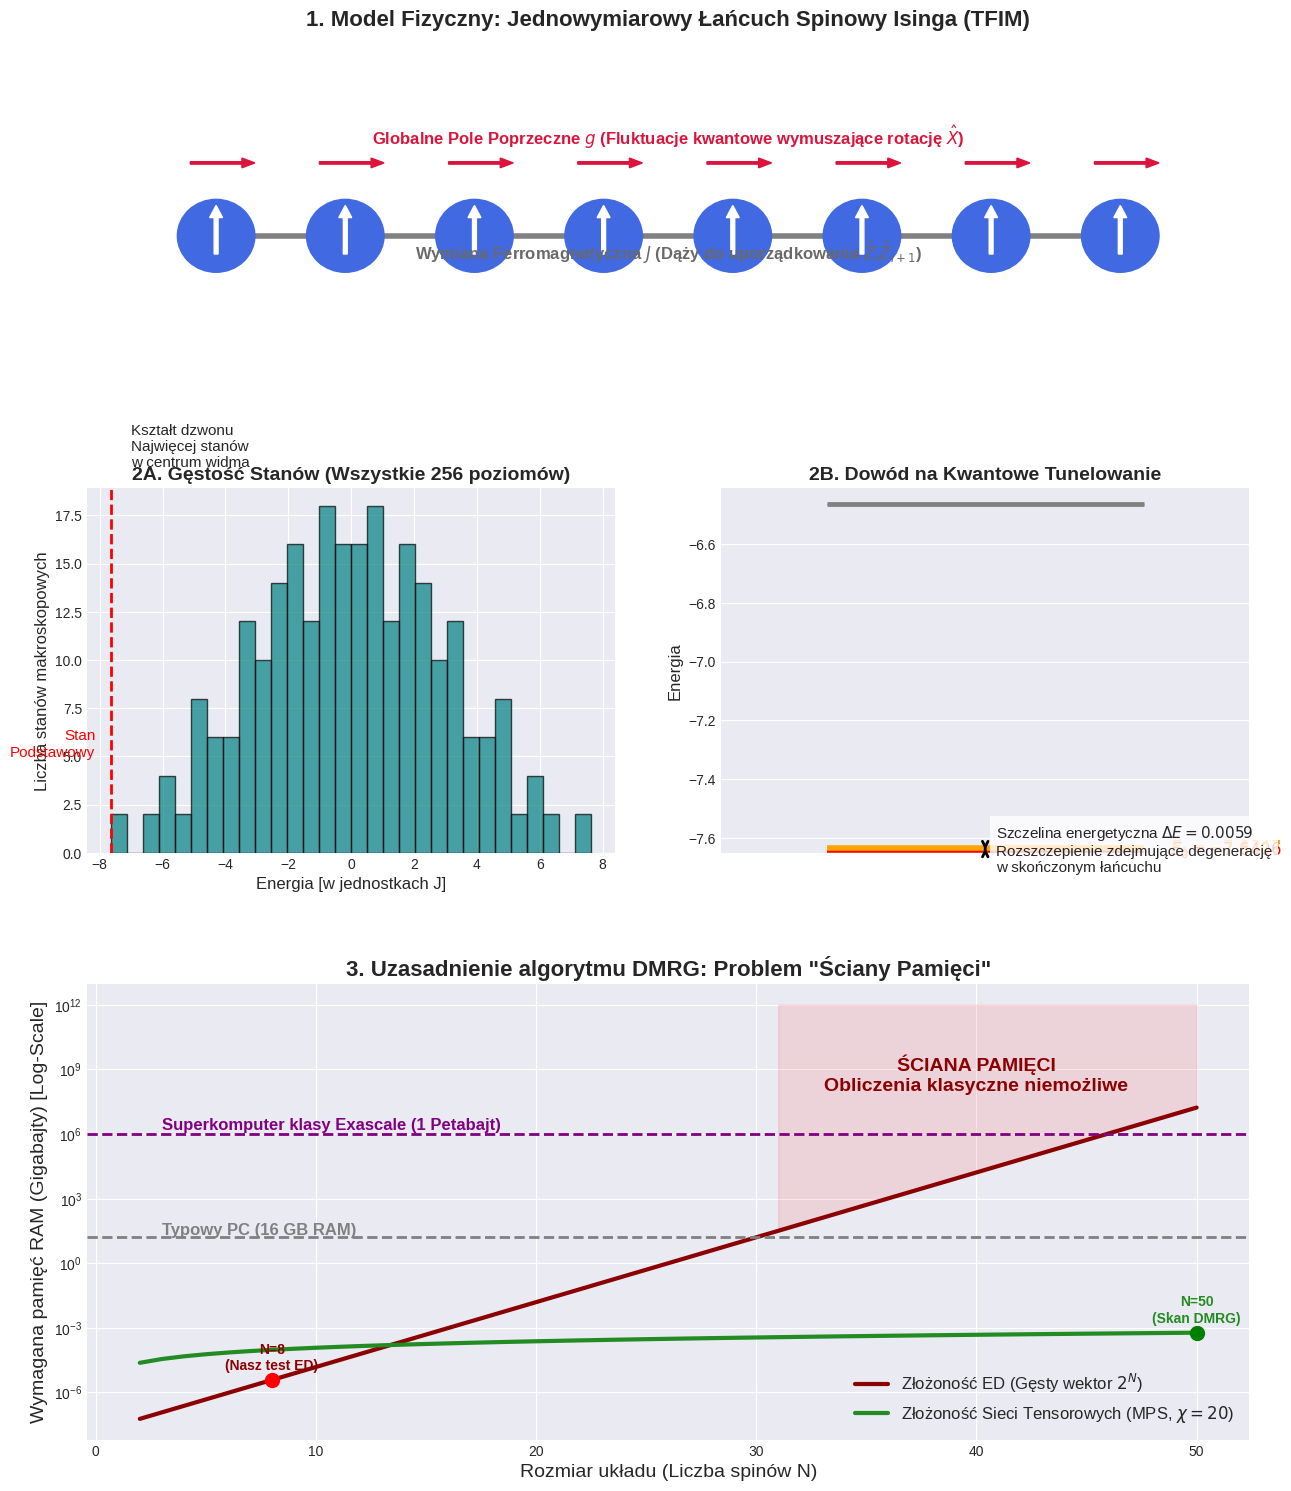

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# --- TWOJE DANE Z DIAGONALIZACJI ŚCISŁEJ (ED) ---
# Wklejone dokładnie Twoje wyniki dla N=8
energies_str = """
-7.6406 -7.6347 -6.4662 -6.4603 -6.1051 -6.0992 -5.7146 -5.7087 -5.3546 -5.3487 -5.0532 -5.0474 -4.9306 -4.9248
-4.8274 -4.8215 -4.6878 -4.6819 -4.5401 -4.5343 -4.1802 -4.179  -4.1743 -4.1732 -3.8788 -3.873  -3.8191 -3.8132
-3.653  -3.6471 -3.5177 -3.5134 -3.5119 -3.5075 -3.4286 -3.4227 -3.2919 -3.286  -3.1523 -3.1464 -3.1272 -3.1214
-3.0046 -2.9988 -2.9014 -2.8955 -2.7672 -2.7618 -2.7614 -2.7559 -2.6446 -2.6388 -2.5414 -2.5355 -2.4018 -2.3959
-2.3433 -2.3374 -2.2541 -2.2483 -2.2401 -2.2342 -2.1175 -2.1116 -2.1004 -2.0946 -1.9779 -1.972  -1.9528 -1.9469
-1.893  -1.8872 -1.8746 -1.8687 -1.727  -1.7211 -1.5928 -1.5917 -1.5873 -1.5869 -1.5858 -1.5815 -1.367  -1.3658
-1.3611 -1.36   -1.2317 -1.2274 -1.2262 -1.2258 -1.2215 -1.2204 -1.0656 -1.0598 -1.0059 -1.     -0.926  -0.9202
-0.8663 -0.8604 -0.8412 -0.8353 -0.7186 -0.7127 -0.7045 -0.7002 -0.6987 -0.6943 -0.6154 -0.6095 -0.5649 -0.5591
-0.4758 -0.4699 -0.4173 -0.4114 -0.3391 -0.3332 -0.314  -0.3082 -0.1914 -0.1856 -0.1744 -0.1686 -0.0573 -0.0518
-0.0514 -0.046   0.046   0.0514  0.0518  0.0573  0.1686  0.1744  0.1856  0.1914  0.3082  0.314   0.3332  0.3391
 0.4114  0.4173  0.4699  0.4758  0.5591  0.5649  0.6095  0.6154  0.6943  0.6987  0.7002  0.7045  0.7127  0.7186
 0.8353  0.8412  0.8604  0.8663  0.9202  0.926   1.      1.0059  1.0598  1.0656  1.2204  1.2215  1.2258  1.2262
 1.2274  1.2317  1.36    1.3611  1.3658  1.367   1.5815  1.5858  1.5869  1.5873  1.5917  1.5928  1.7211  1.727
 1.8687  1.8746  1.8872  1.893   1.9469  1.9528  1.972   1.9779  2.0946  2.1004  2.1116  2.1175  2.2342  2.2401
 2.2483  2.2541  2.3374  2.3433  2.3959  2.4018  2.5355  2.5414  2.6388  2.6446  2.7559  2.7614  2.7618  2.7672
 2.8955  2.9014  2.9988  3.0046  3.1214  3.1272  3.1464  3.1523  3.286   3.2919  3.4227  3.4286  3.5075  3.5119
 3.5134  3.5177  3.6471  3.653   3.8132  3.8191  3.873   3.8788  4.1732  4.1743  4.179   4.1802  4.5343  4.5401
 4.6819  4.6878  4.8215  4.8274  4.9248  4.9306  5.0474  5.0532  5.3487  5.3546  5.7087  5.7146  6.0992  6.1051
 6.4603  6.4662  7.6347  7.6406
"""
# Parsowanie stringa do tablicy numpy
energies = np.array([float(x) for x in energies_str.split()])
E0, E1 = energies[0], energies[1]
gap = np.abs(E1 - E0)

# Ustawienia ogólne wykresu
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(15, 18))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1.2, 1.5], hspace=0.35, wspace=0.2)

# ==============================================================================
# 1. WIZUALIZACJA UKŁADU FIZYCZNEGO (Góra, cała szerokość)
# ==============================================================================
ax_sys = fig.add_subplot(gs[0, :])
ax_sys.set_title("1. Model Fizyczny: Jednowymiarowy Łańcuch Spinowy Isinga (TFIM)", fontsize=16, fontweight='bold', pad=20)
ax_sys.axis('off')

# Rysowanie spinów (N=8)
N_spins = 8
x_pos = np.arange(N_spins)
y_pos = np.zeros(N_spins)

# Linia wiązań (Oddziaływanie J)
ax_sys.plot(x_pos, y_pos, color='grey', linewidth=4, zorder=1)

for i in range(N_spins):
    # Kółko oznaczające kubit
    circle = plt.Circle((x_pos[i], y_pos[i]), 0.3, color='royalblue', zorder=2)
    ax_sys.add_patch(circle)
    # Strzałka spinu (zakładamy stan ferromagnetyczny Up)
    ax_sys.arrow(x_pos[i], y_pos[i]-0.15, 0, 0.3, color='white', head_width=0.1, head_length=0.1, width=0.03, zorder=3)
    # Pole poprzeczne g (fluktuacje x)
    ax_sys.arrow(x_pos[i]-0.2, y_pos[i]+0.6, 0.4, 0, color='crimson', head_width=0.08, head_length=0.1, width=0.02)

ax_sys.text(N_spins/2 - 0.5, 0.75, "Globalne Pole Poprzeczne $g$ (Fluktuacje kwantowe wymuszające rotację $\hat{X}$)", 
            color='crimson', fontsize=12, ha='center', fontweight='bold')
ax_sys.text(N_spins/2 - 0.5, -0.2, "Wymiana Ferromagnetyczna $J$ (Dąży do uporządkowania $\hat{Z}_i \hat{Z}_{i+1}$)", 
            color='dimgrey', fontsize=12, ha='center', fontweight='bold')

ax_sys.set_xlim(-1, N_spins)
ax_sys.set_ylim(-1, 1.5)


# ==============================================================================
# 2. WIDMO ENERGETYCZNE: Gęstość Stanów (Lewy Środek)
# ==============================================================================
ax_dos = fig.add_subplot(gs[1, 0])
ax_dos.hist(energies, bins=30, color='teal', alpha=0.7, edgecolor='black')
ax_dos.set_title("2A. Gęstość Stanów (Wszystkie 256 poziomów)", fontsize=14, fontweight='bold')
ax_dos.set_xlabel("Energia [w jednostkach J]", fontsize=12)
ax_dos.set_ylabel("Liczba stanów makroskopowych", fontsize=12)
ax_dos.text(-7, 20, "Kształt dzwonu\nNajwięcej stanów\nw centrum widma", fontsize=11, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Zaznaczenie stanu podstawowego na histogramie
ax_dos.axvline(E0, color='red', linestyle='--', linewidth=2)
ax_dos.text(E0-0.5, 5, "Stan\nPodstawowy", color='red', ha='right', fontsize=11)


# ==============================================================================
# 3. KWANTOWE TUNELOWANIE (Prawy Środek - Zoom na E0 i E1)
# ==============================================================================
ax_zoom = fig.add_subplot(gs[1, 1])
# Wykres poziomów jako linie (drabinka)
x_line = [0.2, 0.8]
ax_zoom.hlines(y=[E0, E1, energies[2], energies[3]], xmin=x_line[0], xmax=x_line[1], 
               colors=['red', 'orange', 'grey', 'grey'], linewidth=[4, 4, 2, 2])

ax_zoom.set_title("2B. Dowód na Kwantowe Tunelowanie", fontsize=14, fontweight='bold')
ax_zoom.set_ylabel("Energia", fontsize=12)
ax_zoom.set_xlim(0, 1)
ax_zoom.set_ylim(E0 - 0.01, energies[3] + 0.05)
ax_zoom.set_xticks([]) # Ukrycie osi X, bo jest tu bez znaczenia

# Adnotacje
ax_zoom.text(0.85, E0, f"$E_0 = {E0:.4f}$", va='center', color='red', fontsize=12, fontweight='bold')
ax_zoom.text(0.85, E1, f"$E_1 = {E1:.4f}$", va='center', color='orange', fontsize=12, fontweight='bold')

# Szczelina energetyczna
ax_zoom.annotate('', xy=(0.5, E0), xytext=(0.5, E1),
                 arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax_zoom.text(0.52, (E0+E1)/2, f"Szczelina energetyczna $\Delta E = {gap:.4f}$\nRozszczepienie zdejmujące degenerację\nw skończonym łańcuchu", 
             va='center', fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))


# ==============================================================================
# 4. ŚCIANA PAMIĘCI: Dlaczego potrzebujemy MPS/DMRG? (Dół, cała szerokość)
# ==============================================================================
ax_mem = fig.add_subplot(gs[2, :])

N_range = np.arange(2, 51)
bytes_per_complex = 16

# Pamięć dla gęstego wektora (Exact Diagonalization)
mem_ed_bytes = (2**N_range) * bytes_per_complex
mem_ed_gb = mem_ed_bytes / (1024**3)

# Pamięć dla Matrix Product State (DMRG) - przybliżenie dla wymiaru wiązania chi=20
chi = 20
mem_mps_bytes = N_range * (2 * chi**2) * bytes_per_complex
mem_mps_gb = mem_mps_bytes / (1024**3)

ax_mem.plot(N_range, mem_ed_gb, color='darkred', linewidth=3, label="Złożoność ED (Gęsty wektor $2^N$)")
ax_mem.plot(N_range, mem_mps_gb, color='forestgreen', linewidth=3, label="Złożoność Sieci Tensorowych (MPS, $\chi=20$)")

ax_mem.set_yscale('log')
ax_mem.set_title("3. Uzasadnienie algorytmu DMRG: Problem \"Ściany Pamięci\"", fontsize=16, fontweight='bold')
ax_mem.set_xlabel("Rozmiar układu (Liczba spinów N)", fontsize=14)
ax_mem.set_ylabel("Wymagana pamięć RAM (Gigabajty) [Log-Scale]", fontsize=14)

# Zaznaczenie typowych limitów sprzętowych
ax_mem.axhline(16, color='grey', linestyle='--', linewidth=2)
ax_mem.text(3, 20, "Typowy PC (16 GB RAM)", color='grey', fontsize=12, fontweight='bold')

ax_mem.axhline(1024*1000, color='purple', linestyle='--', linewidth=2)
ax_mem.text(3, 1.5e6, "Superkomputer klasy Exascale (1 Petabajt)", color='purple', fontsize=12, fontweight='bold')

# Punkty szczególne
ax_mem.plot(8, mem_ed_gb[6], 'ro', markersize=10)
ax_mem.text(8, mem_ed_gb[6]*3, "N=8\n(Nasz test ED)", ha='center', color='darkred', fontweight='bold')

ax_mem.plot(50, mem_mps_gb[48], 'go', markersize=10)
ax_mem.text(50, mem_mps_gb[48]*3, "N=50\n(Skan DMRG)", ha='center', color='forestgreen', fontweight='bold')

ax_mem.fill_between(N_range, mem_ed_gb, 1e12, where=(mem_ed_gb > 16), color='red', alpha=0.1)
ax_mem.text(40, 1e8, "ŚCIANA PAMIĘCI\nObliczenia klasyczne niemożliwe", color='darkred', ha='center', fontsize=14, fontweight='bold')

ax_mem.legend(loc="lower right", fontsize=12)

plt.show()

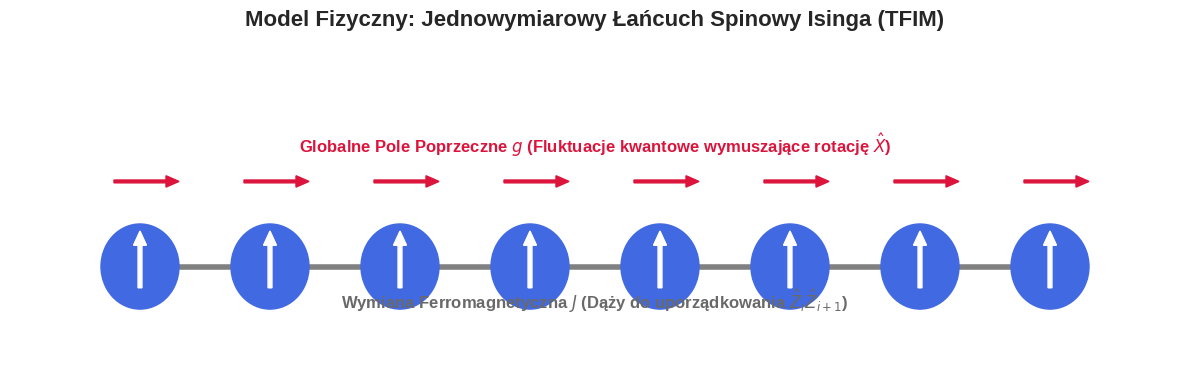

In [27]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title("Model Fizyczny: Jednowymiarowy Łańcuch Spinowy Isinga (TFIM)", fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

N_spins = 8
x_pos = np.arange(N_spins)
y_pos = np.zeros(N_spins)

# Linia wiązań (Oddziaływanie J)
ax.plot(x_pos, y_pos, color='grey', linewidth=4, zorder=1)

for i in range(N_spins):
    # Kółko oznaczające kubit
    circle = plt.Circle((x_pos[i], y_pos[i]), 0.3, color='royalblue', zorder=2)
    ax.add_patch(circle)
    # Strzałka spinu
    ax.arrow(x_pos[i], y_pos[i]-0.15, 0, 0.3, color='white', head_width=0.1, head_length=0.1, width=0.03, zorder=3)
    # Pole poprzeczne g (fluktuacje)
    ax.arrow(x_pos[i]-0.2, y_pos[i]+0.6, 0.4, 0, color='crimson', head_width=0.08, head_length=0.1, width=0.02)

ax.text(N_spins/2 - 0.5, 0.8, "Globalne Pole Poprzeczne $g$ (Fluktuacje kwantowe wymuszające rotację $\hat{X}$)", 
            color='crimson', fontsize=12, ha='center', fontweight='bold')
ax.text(N_spins/2 - 0.5, -0.3, "Wymiana Ferromagnetyczna $J$ (Dąży do uporządkowania $\hat{Z}_i \hat{Z}_{i+1}$)", 
            color='dimgrey', fontsize=12, ha='center', fontweight='bold')

ax.set_xlim(-1, N_spins)
ax.set_ylim(-0.8, 1.5)
plt.tight_layout()
plt.show()

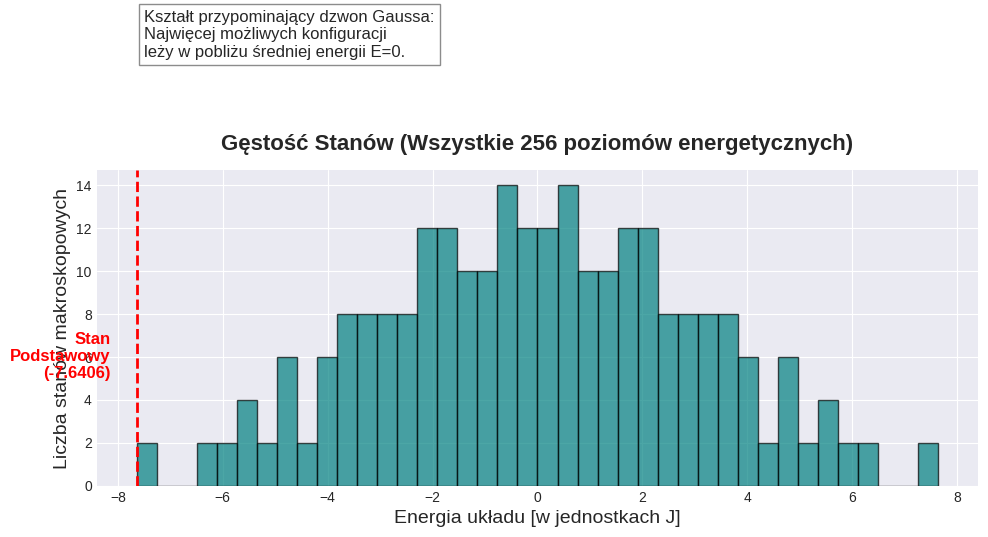

In [ ]:
energies = E0_manual # np.array([float(x) for x in energies_str.split()])
E0 = energies[0]

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(energies, bins=40, color='teal', alpha=0.7, edgecolor='black')
ax.set_title("Gęstość Stanów (Wszystkie 256 poziomów energetycznych)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Energia układu [w jednostkach J]", fontsize=14)
ax.set_ylabel("Liczba stanów makroskopowych", fontsize=14)

# Zaznaczenie stanu podstawowego
ax.axvline(E0, color='red', linestyle='--', linewidth=2)
ax.text(E0 - 0.5, 5, "Stan\nPodstawowy\n(-7.6406)", color='red', ha='right', fontsize=12, fontweight='bold')
ax.text(-7.5, 20, "Kształt przypominający dzwon Gaussa:\nNajwięcej możliwych konfiguracji\nleży w pobliżu średniej energii E=0.", 
        fontsize=12, bbox=dict(facecolor='white', alpha=0.9, edgecolor='grey'))

plt.tight_layout()
plt.show()

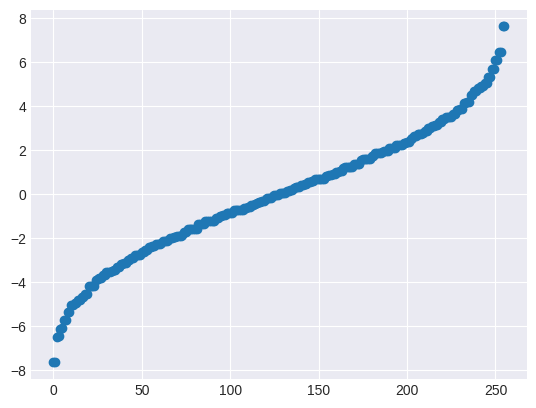

In [39]:
energies = E0_manual # np.array([float(x) for x in energies_str.split()])
plt.plot(energies, "o")

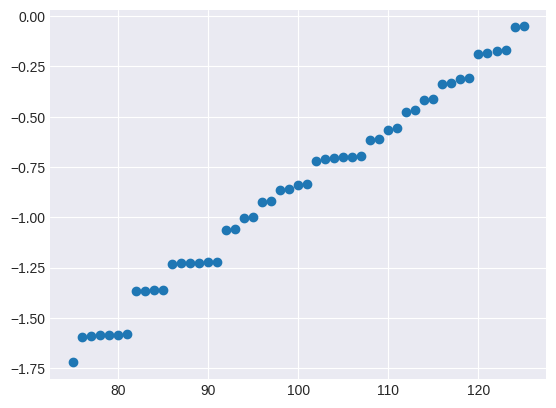

In [44]:
range_plot = range(75, 126)
plt.plot(range_plot, energies[range_plot], "o")

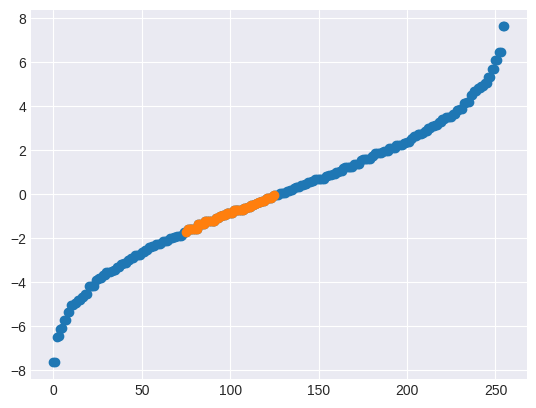

In [45]:
plt.plot(energies, "o")
plt.plot(range_plot, energies[range_plot], "o")

# Eksperyment 3: Złożone Układy Kwantowe - Algorytm DMRG i Kwantowe Przejście Fazowe
Ścisła diagonalizacja spłaszcza tensory do gigantycznych macierzy (w naszym przypadku $256 \times 256$). Dla $N=50$ przestrzen Hilberta to $2^{50}$, a pełna macierz zabiłaby każdy konwencjonalny superkomputer.Wykorzystamy teraz kwintesencję analizy układów złożonych – Density Matrix Renormalization Group (DMRG). Będziemy wariacyjnie optymalizować tensory stanu MPS w celu znalezienia stanu podstawowego układu $N=50$ spinów, operując jedynie na sieciach tensorowych.Co więcej, przeprowadzimy fizyczny skan parametru pola poprzecznego $g \in [0.1, 2.0]$. Ponieważ jest to kwantowy model Isinga w temperaturze zerowej ($T=0$), spodziewamy się Kwantowego Przejścia Fazowego (Quantum Phase Transition - QPT) dokładnie dla $g = J = 1.0$.W przejściu fazowym, lokalne korelację zrywają 1D Area Law, a entropia splątania powinna zyskać nielokalne fluktuacje.Zbadamy to wyliczając Entropię Splątania von Neumanna $S(\rho_A) = -\text{Tr}(\rho_A \log \rho_A)$ na samym środku układu po przecięciu go na dwie połowy $A$ i $B$.

In [ ]:
N_large = 50
J_val = 1.0
a, b = 0.1, 2.0
n = 200
mu = 1.0           # środek dzwonu
sigma = 0.1       # im mniejsze, tym ostrzejszy pik przy 1

t = np.linspace(0, 1, n)
x = mu + sigma * np.sqrt(2) * erfinv(2*t - 1)

# obcinamy do [a, b] na wszelki wypadek
g_values = np.clip(x, a, b)

magnetizations_x = []
entanglement_entropies = []

print(f"Rozpoczynamy skanowanie Kwantowego Przejścia Fazowego (DMRG) dla {N_large} spinów...")

for g in g_values:
    # 1. Definiujemy Hamiltonian dla bieżącego pola 'g'
    H_mpo = qtn.MPO_ham_ising(L=N_large, j=4.0*J_val, bx=2.0*g)
    
    # 2. Silnik DMRG - ograniczenie splątania przez max_bond=20 
    dmrg = qtn.DMRG2(H_mpo, bond_dims=20, cutoffs=1e-10)
    dmrg.solve(tol=1e-5, verbosity=0)
    
    # Uzyskany stan podstawowy jako struktura MPS
    psi0 = dmrg.state
    
    # 3. FIZYKA: Lokalna magnetyzacja w kierunku X na środkowym spinie (wpływ pola poprzecznego)
    # Zwróć uwagę jak quimb pozwala na eleganckie operacje na fizycznych właściwościach grafu.
    mag_x = psi0.magnetization(N_large//2, direction='X')
    magnetizations_x.append(mag_x)
    
    # 4. FIZYKA: Entropia Splątania dla połówki układu (Bipartite Entanglement Entropy)
    # Metoda.entropy robi dekompozycję Schmidta (SVD) w zadanym punkcie przecięcia grafu
    S_entropy = psi0.entropy(N_large//2)
    entanglement_entropies.append(S_entropy)

Rozpoczynamy skanowanie Kwantowego Przejścia Fazowego (DMRG) dla 50 spinów...


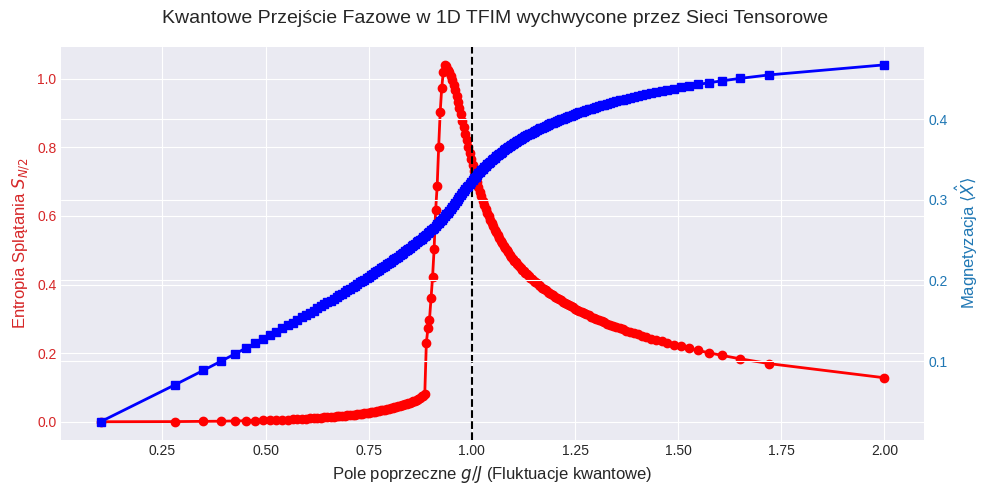

In [60]:
# Wizualizacja danych fizycznych
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'tab:red'
ax1.set_xlabel('Pole poprzeczne $g/J$ (Fluktuacje kwantowe)', fontsize=12)
ax1.set_ylabel('Entropia Splątania $S_{N/2}$', color=color1, fontsize=12)
ax1.plot(g_values, entanglement_entropies, 'ro-', linewidth=2, label='Entropia')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axvline(x=1.0, color='k', linestyle='--', label='Punkt Krytyczny QPT')

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Magnetyzacja $\\langle \hat{X} \\rangle$', color=color2, fontsize=12)
ax2.plot(g_values, magnetizations_x, 'bs-', linewidth=2, label='Magnetyzacja')
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('Kwantowe Przejście Fazowe w 1D TFIM wychwycone przez Sieci Tensorowe', fontsize=14)
fig.tight_layout()
plt.show()

Rozpoczynamy skanowanie Kwantowego Przejścia Fazowego (DMRG) dla 200 spinów...


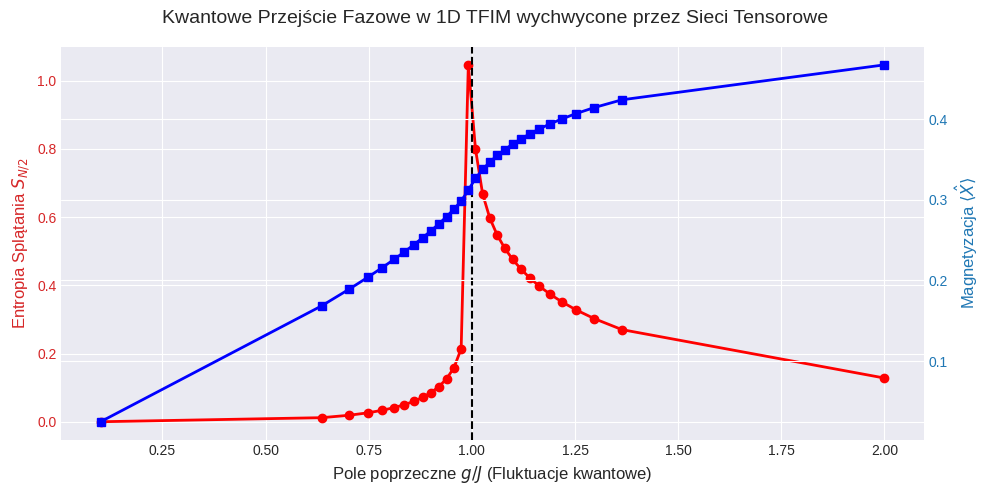

In [72]:
N_large = 200
J_val = 1.0
a, b = 0.1, 2.0
n = 30
mu = 1           # środek dzwonu
sigma = 0.2       # im mniejsze, tym ostrzejszy pik przy 1

t = np.linspace(0, 1, n)
x = mu + sigma * np.sqrt(2) * erfinv(2*t - 1)

# obcinamy do [a, b] na wszelki wypadek
g_values = np.clip(x, a, b)

magnetizations_x = []
entanglement_entropies = []

print(f"Rozpoczynamy skanowanie Kwantowego Przejścia Fazowego (DMRG) dla {N_large} spinów...")

for g in g_values:
    # 1. Definiujemy Hamiltonian dla bieżącego pola 'g'
    H_mpo = qtn.MPO_ham_ising(L=N_large, j=4.0*J_val, bx=2.0*g)
    
    # 2. Silnik DMRG - ograniczenie splątania przez max_bond=20 
    dmrg = qtn.DMRG2(H_mpo, bond_dims=20, cutoffs=1e-10)
    dmrg.solve(tol=1e-5, verbosity=0)
    
    # Uzyskany stan podstawowy jako struktura MPS
    psi0 = dmrg.state
    
    # 3. FIZYKA: Lokalna magnetyzacja w kierunku X na środkowym spinie (wpływ pola poprzecznego)
    # Zwróć uwagę jak quimb pozwala na eleganckie operacje na fizycznych właściwościach grafu.
    mag_x = psi0.magnetization(N_large//2, direction='X')
    magnetizations_x.append(mag_x)
    
    # 4. FIZYKA: Entropia Splątania dla połówki układu (Bipartite Entanglement Entropy)
    # Metoda.entropy robi dekompozycję Schmidta (SVD) w zadanym punkcie przecięcia grafu
    S_entropy = psi0.entropy(N_large//2)
    entanglement_entropies.append(S_entropy)

# Wizualizacja danych fizycznych
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'tab:red'
ax1.set_xlabel('Pole poprzeczne $g/J$ (Fluktuacje kwantowe)', fontsize=12)
ax1.set_ylabel('Entropia Splątania $S_{N/2}$', color=color1, fontsize=12)
ax1.plot(g_values, entanglement_entropies, 'ro-', linewidth=2, label='Entropia')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axvline(x=1.0, color='k', linestyle='--', label='Punkt Krytyczny QPT')

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Magnetyzacja $\\langle \hat{X} \\rangle$', color=color2, fontsize=12)
ax2.plot(g_values, magnetizations_x, 'bs-', linewidth=2, label='Magnetyzacja')
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('Kwantowe Przejście Fazowe w 1D TFIM wychwycone przez Sieci Tensorowe', fontsize=14)
fig.tight_layout()
plt.show()

In [75]:
import numpy as np
import quimb.tensor as qtn
import matplotlib.pyplot as plt
from scipy.special import erfinv
import io
from PIL import Image

def find_critical_point_prescan(N, J_val, a, b, num_points=15):
    """
    Wykonuje szybki, rzadki skan, aby zlokalizować pik entropii 
    zmniejszając max_bond w celu przyspieszenia obliczeń.
    """
    g_coarse = np.linspace(a, b, num_points)
    entropies = []
    
    for g in g_coarse:
        H_mpo = qtn.MPO_ham_ising(L=N, j=4.0*J_val, bx=2.0*g)
        # Używamy małego bond_dims do błyskawicznego rozeznania (chi=10)
        dmrg = qtn.DMRG2(H_mpo, bond_dims=10, cutoffs=1e-8)
        dmrg.solve(tol=1e-4, verbosity=0)
        
        entropies.append(dmrg.state.entropy(N//2))
        
    # Zwracamy wartość 'g', dla której entropia była największa
    return g_coarse[np.argmax(entropies)]

def generate_qpt_gif_adaptive(N_list, filename="QPT_evolution_adaptive.gif", duration_ms=800):
    J_val = 1.0
    a, b = 0.1, 2.0
    n_dense = 50 # Liczba punktów w głównym, gęstym skanowaniu
    sigma = 0.35  # Skupienie wokół piku (im mniejsze, tym ciaśniej)

    frames = [] 
    print(f"Rozpoczynam adaptacyjne generowanie symulacji dla N: {N_list}")

    for N_large in N_list:
        print(f"\n--- Przetwarzanie N = {N_large} ---")
        
        # --- ETAP 1: PRE-SCAN ---
        print("Krok 1: Szybki skan wstępny (szukanie piku)...")
        mu_adaptive = find_critical_point_prescan(N_large, J_val, a, b)
        print(f"Zlokalizowano przesunięty punkt krytyczny przy g ≈ {mu_adaptive:.3f}")
        
        # --- ETAP 2: GENEROWANIE ADAPTACYJNEJ SIATKI ---
        t = np.linspace(0.01, 0.99, n_dense)
        # Centrujemy rozkład wokół nowo znalezionego 'mu_adaptive'
        x = mu_adaptive + sigma * np.sqrt(2) * erfinv(2*t - 1)
        g_values = np.clip(x, a, b)
        
        # Sortowanie punktów jest kluczowe! Po clippingu lub sklejaniu siatek 
        # bez sortowania matplotlib mógłby narysować na wykresie "Zygzaki"
        g_values = np.sort(g_values)

        magnetizations_x = []
        entanglement_entropies = []
        
        # --- ETAP 3: GŁÓWNY, DOKŁADNY SKAN ---
        print("Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...")
        for g in g_values:
            H_mpo = qtn.MPO_ham_ising(L=N_large, j=4.0*J_val, bx=2.0*g)
            
            # Główny silnik z większym chi
            dmrg = qtn.DMRG2(H_mpo, bond_dims=20, cutoffs=1e-10)
            dmrg.solve(tol=1e-5, verbosity=0)
            
            psi0 = dmrg.state
            
            mag_x = psi0.magnetization(N_large//2, direction='X')
            S_entropy = psi0.entropy(N_large//2)
            
            magnetizations_x.append(mag_x)
            entanglement_entropies.append(S_entropy)

        # --- WIZUALIZACJA ---
        fig, ax1 = plt.subplots(figsize=(10, 5))

        color1 = 'tab:red'
        ax1.set_xlabel('Pole poprzeczne $g/J$ (Fluktuacje kwantowe)', fontsize=12)
        ax1.set_ylabel('Entropia Splątania $S_{N/2}$', color=color1, fontsize=12)
        
        # Zaznaczamy gdzie zagęściliśmy punkty używając markera
        ax1.plot(g_values, entanglement_entropies, 'r.-', linewidth=2, markersize=8, label='Entropia')
        ax1.tick_params(axis='y', labelcolor=color1)
        
        # Pokazujemy na wykresie gdzie był idealny g=1, a gdzie nasz znaleziony pik
        ax1.axvline(x=1.0, color='k', linestyle='--', alpha=0.5, label='Teoretyczne $g=1$')
        #ax1.axvline(x=mu_adaptive, color='red', linestyle=':', label=f'Odkryty pik ($g={mu_adaptive:.2f}$)')
        ax1.set_xlim(a, b)

        ax2 = ax1.twinx()
        color2 = 'tab:blue'
        ax2.set_ylabel('Magnetyzacja $\\langle \hat{X} \\rangle$', color=color2, fontsize=12)
        ax2.plot(g_values, magnetizations_x, 'b.-', linewidth=2, markersize=8, label='Magnetyzacja')
        ax2.tick_params(axis='y', labelcolor=color2)
        ax2.set_ylim(-0.05, 1.05)

        fig.suptitle(f'Kwantowe Przejście Fazowe w 1D TFIM | Rozmiar układu: N = {N_large}', fontsize=14)
        
        # Zbieranie legend z obu osi do jednego bloku
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')

        fig.tight_layout()

        # Zapis do bufora
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        
        img = Image.open(buf)
        frames.append(img.copy())
        
        buf.close()
        plt.close(fig)

    print(f"\nZapisywanie animacji do pliku: {filename}...")
    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=0 
    )
    print("Gotowe!")

# Wywołanie dla np. takich N:
lista_N = [20, 30, 40, 50, 60, 100, 200]
generate_qpt_gif_adaptive(N_list=lista_N, filename="Skalowanie_QPT_AdaptiveX30.gif", duration_ms=1000)

Rozpoczynam adaptacyjne generowanie symulacji dla N: [20, 30, 40, 50, 60, 100, 200]

--- Przetwarzanie N = 20 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.779
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 30 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.914
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 40 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.914
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 50 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.914
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 60 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 1.050
Krok 2: Główny ska

In [76]:
import numpy as np
import quimb.tensor as qtn
import matplotlib.pyplot as plt
from scipy.special import erfinv
import io
from PIL import Image

def find_critical_point_prescan(N, J_val, a, b, num_points=15):
    """
    Wykonuje szybki, rzadki skan, aby zlokalizować pik entropii 
    zmniejszając max_bond w celu przyspieszenia obliczeń.
    """
    g_coarse = np.linspace(a, b, num_points)
    entropies = []
    
    for g in g_coarse:
        H_mpo = qtn.MPO_ham_ising(L=N, j=4.0*J_val, bx=2.0*g)
        # Używamy małego bond_dims do błyskawicznego rozeznania (chi=10)
        dmrg = qtn.DMRG2(H_mpo, bond_dims=10, cutoffs=1e-8)
        dmrg.solve(tol=1e-4, verbosity=0)
        
        entropies.append(dmrg.state.entropy(N//2))
        
    # Zwracamy wartość 'g', dla której entropia była największa
    return g_coarse[np.argmax(entropies)]

def generate_qpt_gif_adaptive(N_list, filename="QPT_evolution_adaptive.gif", duration_ms=800):
    J_val = 1.0
    a, b = 0.1, 2.0
    n_dense = 50 # Liczba punktów w głównym, gęstym skanowaniu
    sigma = 0.35  # Skupienie wokół piku (im mniejsze, tym ciaśniej)

    frames = [] 
    print(f"Rozpoczynam adaptacyjne generowanie symulacji dla N: {N_list}")

    for N_large in N_list:
        print(f"\n--- Przetwarzanie N = {N_large} ---")
        
        # --- ETAP 1: PRE-SCAN ---
        print("Krok 1: Szybki skan wstępny (szukanie piku)...")
        mu_adaptive = find_critical_point_prescan(N_large, J_val, a, b)
        print(f"Zlokalizowano przesunięty punkt krytyczny przy g ≈ {mu_adaptive:.3f}")
        
        # --- ETAP 2: GENEROWANIE ADAPTACYJNEJ SIATKI ---
        t = np.linspace(0.01, 0.99, n_dense)
        # Centrujemy rozkład wokół nowo znalezionego 'mu_adaptive'
        x = mu_adaptive + sigma * np.sqrt(2) * erfinv(2*t - 1)
        g_values = np.clip(x, a, b)
        
        # Sortowanie punktów jest kluczowe! Po clippingu lub sklejaniu siatek 
        # bez sortowania matplotlib mógłby narysować na wykresie "Zygzaki"
        g_values = np.sort(g_values)

        magnetizations_x = []
        entanglement_entropies = []
        
        # --- ETAP 3: GŁÓWNY, DOKŁADNY SKAN ---
        print("Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...")
        for g in g_values:
            H_mpo = qtn.MPO_ham_ising(L=N_large, j=4.0*J_val, bx=2.0*g)
            
            # Główny silnik z większym chi
            dmrg = qtn.DMRG2(H_mpo, bond_dims=10, cutoffs=1e-10)
            dmrg.solve(tol=1e-5, verbosity=0)
            
            psi0 = dmrg.state
            
            mag_x = psi0.magnetization(N_large//2, direction='X')
            S_entropy = psi0.entropy(N_large//2)
            
            magnetizations_x.append(mag_x)
            entanglement_entropies.append(S_entropy)

        # --- WIZUALIZACJA ---
        fig, ax1 = plt.subplots(figsize=(10, 5))

        color1 = 'tab:red'
        ax1.set_xlabel('Pole poprzeczne $g/J$ (Fluktuacje kwantowe)', fontsize=12)
        ax1.set_ylabel('Entropia Splątania $S_{N/2}$', color=color1, fontsize=12)
        
        # Zaznaczamy gdzie zagęściliśmy punkty używając markera
        ax1.plot(g_values, entanglement_entropies, 'r.-', linewidth=2, markersize=8, label='Entropia')
        ax1.tick_params(axis='y', labelcolor=color1)
        
        # Pokazujemy na wykresie gdzie był idealny g=1, a gdzie nasz znaleziony pik
        ax1.axvline(x=1.0, color='k', linestyle='--', alpha=0.5, label='Teoretyczne $g=1$')
        #ax1.axvline(x=mu_adaptive, color='red', linestyle=':', label=f'Odkryty pik ($g={mu_adaptive:.2f}$)')
        ax1.set_xlim(a, b)

        ax2 = ax1.twinx()
        color2 = 'tab:blue'
        ax2.set_ylabel('Magnetyzacja $\\langle \hat{X} \\rangle$', color=color2, fontsize=12)
        ax2.plot(g_values, magnetizations_x, 'b.-', linewidth=2, markersize=8, label='Magnetyzacja')
        ax2.tick_params(axis='y', labelcolor=color2)
        ax2.set_ylim(-0.05, 1.05)

        fig.suptitle(f'Kwantowe Przejście Fazowe w 1D TFIM | Rozmiar układu: N = {N_large}', fontsize=14)
        
        # Zbieranie legend z obu osi do jednego bloku
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')

        fig.tight_layout()

        # Zapis do bufora
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        
        img = Image.open(buf)
        frames.append(img.copy())
        
        buf.close()
        plt.close(fig)

    print(f"\nZapisywanie animacji do pliku: {filename}...")
    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=0 
    )
    print("Gotowe!")

# Wywołanie dla np. takich N:
lista_N = [20, 30, 40, 50, 60, 100, 200]
generate_qpt_gif_adaptive(N_list=lista_N, filename="Skalowanie_QPT_AdaptiveX10.gif", duration_ms=1000)

Rozpoczynam adaptacyjne generowanie symulacji dla N: [20, 30, 40, 50, 60, 100, 200]

--- Przetwarzanie N = 20 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.779
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 30 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.914
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 40 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.914
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 50 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 1.050
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 60 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 1.050
Krok 2: Główny ska

In [77]:
import numpy as np
import quimb.tensor as qtn
import matplotlib.pyplot as plt
from scipy.special import erfinv
import io
from PIL import Image

def find_critical_point_prescan(N, J_val, a, b, num_points=15):
    """
    Wykonuje szybki, rzadki skan, aby zlokalizować pik entropii 
    zmniejszając max_bond w celu przyspieszenia obliczeń.
    """
    g_coarse = np.linspace(a, b, num_points)
    entropies = []
    
    for g in g_coarse:
        H_mpo = qtn.MPO_ham_ising(L=N, j=4.0*J_val, bx=2.0*g)
        # Używamy małego bond_dims do błyskawicznego rozeznania (chi=10)
        dmrg = qtn.DMRG2(H_mpo, bond_dims=10, cutoffs=1e-8)
        dmrg.solve(tol=1e-4, verbosity=0)
        
        entropies.append(dmrg.state.entropy(N//2))
        
    # Zwracamy wartość 'g', dla której entropia była największa
    return g_coarse[np.argmax(entropies)]

def generate_qpt_gif_adaptive(N_list, filename="QPT_evolution_adaptive.gif", duration_ms=800):
    J_val = 1.0
    a, b = 0.1, 2.0
    n_dense = 50 # Liczba punktów w głównym, gęstym skanowaniu
    sigma = 0.35  # Skupienie wokół piku (im mniejsze, tym ciaśniej)

    frames = [] 
    print(f"Rozpoczynam adaptacyjne generowanie symulacji dla N: {N_list}")

    for N_large in N_list:
        print(f"\n--- Przetwarzanie N = {N_large} ---")
        
        # --- ETAP 1: PRE-SCAN ---
        print("Krok 1: Szybki skan wstępny (szukanie piku)...")
        mu_adaptive = find_critical_point_prescan(N_large, J_val, a, b)
        print(f"Zlokalizowano przesunięty punkt krytyczny przy g ≈ {mu_adaptive:.3f}")
        
        # --- ETAP 2: GENEROWANIE ADAPTACYJNEJ SIATKI ---
        t = np.linspace(0.01, 0.99, n_dense)
        # Centrujemy rozkład wokół nowo znalezionego 'mu_adaptive'
        x = mu_adaptive + sigma * np.sqrt(2) * erfinv(2*t - 1)
        g_values = np.clip(x, a, b)
        
        # Sortowanie punktów jest kluczowe! Po clippingu lub sklejaniu siatek 
        # bez sortowania matplotlib mógłby narysować na wykresie "Zygzaki"
        g_values = np.sort(g_values)

        magnetizations_x = []
        entanglement_entropies = []
        
        # --- ETAP 3: GŁÓWNY, DOKŁADNY SKAN ---
        print("Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...")
        for g in g_values:
            H_mpo = qtn.MPO_ham_ising(L=N_large, j=4.0*J_val, bx=2.0*g)
            
            # Główny silnik z większym chi
            dmrg = qtn.DMRG2(H_mpo, bond_dims=5, cutoffs=1e-10)
            dmrg.solve(tol=1e-5, verbosity=0)
            
            psi0 = dmrg.state
            
            mag_x = psi0.magnetization(N_large//2, direction='X')
            S_entropy = psi0.entropy(N_large//2)
            
            magnetizations_x.append(mag_x)
            entanglement_entropies.append(S_entropy)

        # --- WIZUALIZACJA ---
        fig, ax1 = plt.subplots(figsize=(10, 5))

        color1 = 'tab:red'
        ax1.set_xlabel('Pole poprzeczne $g/J$ (Fluktuacje kwantowe)', fontsize=12)
        ax1.set_ylabel('Entropia Splątania $S_{N/2}$', color=color1, fontsize=12)
        
        # Zaznaczamy gdzie zagęściliśmy punkty używając markera
        ax1.plot(g_values, entanglement_entropies, 'r.-', linewidth=2, markersize=8, label='Entropia')
        ax1.tick_params(axis='y', labelcolor=color1)
        
        # Pokazujemy na wykresie gdzie był idealny g=1, a gdzie nasz znaleziony pik
        ax1.axvline(x=1.0, color='k', linestyle='--', alpha=0.5, label='Teoretyczne $g=1$')
        #ax1.axvline(x=mu_adaptive, color='red', linestyle=':', label=f'Odkryty pik ($g={mu_adaptive:.2f}$)')
        ax1.set_xlim(a, b)

        ax2 = ax1.twinx()
        color2 = 'tab:blue'
        ax2.set_ylabel('Magnetyzacja $\\langle \hat{X} \\rangle$', color=color2, fontsize=12)
        ax2.plot(g_values, magnetizations_x, 'b.-', linewidth=2, markersize=8, label='Magnetyzacja')
        ax2.tick_params(axis='y', labelcolor=color2)
        ax2.set_ylim(-0.05, 1.05)

        fig.suptitle(f'Kwantowe Przejście Fazowe w 1D TFIM | Rozmiar układu: N = {N_large}', fontsize=14)
        
        # Zbieranie legend z obu osi do jednego bloku
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')

        fig.tight_layout()

        # Zapis do bufora
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        
        img = Image.open(buf)
        frames.append(img.copy())
        
        buf.close()
        plt.close(fig)

    print(f"\nZapisywanie animacji do pliku: {filename}...")
    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=0 
    )
    print("Gotowe!")

# Wywołanie dla np. takich N:
lista_N = [20, 30, 40, 50, 60, 100, 200]
generate_qpt_gif_adaptive(N_list=lista_N, filename="Skalowanie_QPT_AdaptiveX5.gif", duration_ms=1000)

Rozpoczynam adaptacyjne generowanie symulacji dla N: [20, 30, 40, 50, 60, 100, 200]

--- Przetwarzanie N = 20 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.779
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 30 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.914
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 40 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.914
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 50 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 0.914
Krok 2: Główny skan DMRG (Wysoka precyzja wokół piku)...

--- Przetwarzanie N = 60 ---
Krok 1: Szybki skan wstępny (szukanie piku)...
Zlokalizowano przesunięty punkt krytyczny przy g ≈ 1.050
Krok 2: Główny ska

In [82]:
import numpy as np
import quimb as qu
import quimb.tensor as qtn
import matplotlib.pyplot as plt

N = 20 # Zmniejszamy układ, by komputer przetrwał liczenie gęstej macierzy dla pierścienia!
J_val = 1.0
g_values = np.linspace(0.1, 2.0, 40)

# Listy na wyniki
mag_obc_list, ent_obc_list = [], []
mag_pbc_list, ent_pbc_list = [], []

print(f"Rozpoczynam mordercze porównanie OBC vs PBC dla N={N} spinów...")

for g in g_values:
    # ==========================================
    # 1. UKŁAD OTWARTY (OBC - Zwykły Łańcuch)
    # ==========================================
    H_obc = qtn.MPO_ham_ising(L=N, j=4.0*J_val, bx=2.0*g, cyclic=False)
    dmrg_obc = qtn.DMRG2(H_obc, bond_dims=20, cutoffs=1e-10)
    dmrg_obc.solve(tol=1e-5, verbosity=0)
    psi_obc = dmrg_obc.state
    
    # Szybkie, wbudowane metody dla OBC
    mag_obc_list.append(psi_obc.magnetization(N//2, direction='X'))
    ent_obc_list.append(psi_obc.entropy(N//2))
    
    # ==========================================
    # 2. UKŁAD ZAMKNIĘTY (PBC - Pierścień/Opona)
    # ==========================================
    H_pbc = qtn.MPO_ham_ising(L=N, j=4.0*J_val, bx=2.0*g, cyclic=True)
    dmrg_pbc = qtn.DMRG2(H_pbc, bond_dims=20, cutoffs=1e-10)
    dmrg_pbc.solve(tol=1e-5, verbosity=0)
    psi_pbc = dmrg_pbc.state
    
    # Magnetyzacja (Ręczna wartość oczekiwana)
    X_op = np.array([[0, 1], [1, 0]])
    psi_X = psi_pbc.gate(X_op, N//2)
    mag_pbc_list.append((psi_pbc.H @ psi_X).real)
    
    # Entropia (Częściowy Ślad -> MPO -> Gęsta Macierz -> Entropia von Neumanna)
    # Wyciągamy podukład A (pierwsza połowa pierścienia)
    rho_mpo = psi_pbc.partial_trace_to_mpo(keep=range(N//2)) 
    rho_dense = rho_mpo.to_dense() # Zamiana na gęstą zredukowaną macierz gęstości
    ent_pbc_list.append(qu.entropy(rho_dense)) # Liczymy entropię

print("Gotowe! Rysujemy wyniki...")

Rozpoczynam mordercze porównanie OBC vs PBC dla N=20 spinów...
Gotowe! Rysujemy wyniki...


ValueError: 
$\langle \hat{X} angle$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x7ecae7f64310> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$\langle \hat{X} angle$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$\langle \hat{X} angle$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1400x600 with 2 Axes>

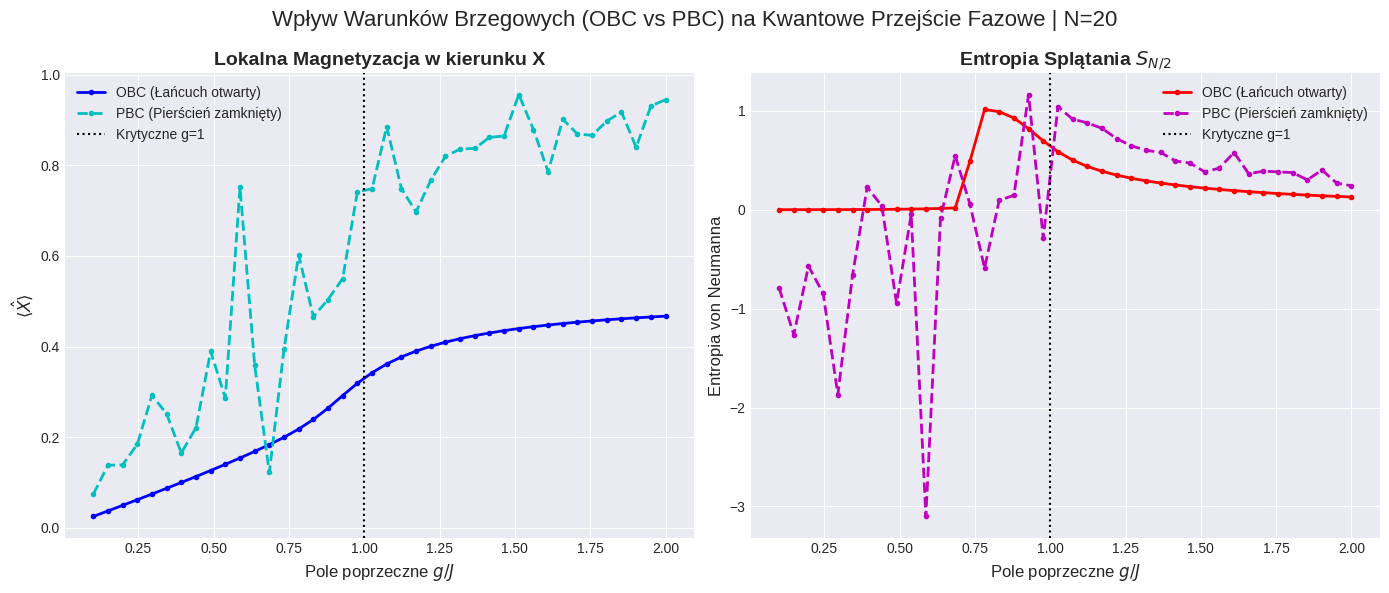

In [83]:
# ==========================================
# WIZUALIZACJA PORÓWNAWCZA
# ==========================================
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Wykres 1: Magnetyzacja
ax1.plot(g_values, mag_obc_list, 'b.-', label="OBC (Łańcuch otwarty)", linewidth=2)
ax1.plot(g_values, mag_pbc_list, 'c.--', label="PBC (Pierścień zamknięty)", linewidth=2)
ax1.set_title("Lokalna Magnetyzacja w kierunku X", fontsize=14, fontweight='bold')
ax1.set_xlabel("Pole poprzeczne $g/J$", fontsize=12)
ax1.set_ylabel("$\\langle \hat{X} \\rangle$", fontsize=12)
ax1.axvline(x=1.0, color='k', linestyle=':', label='Krytyczne g=1')
ax1.legend()

# Wykres 2: Entropia Splątania
ax2.plot(g_values, ent_obc_list, 'r.-', label="OBC (Łańcuch otwarty)", linewidth=2)
ax2.plot(g_values, ent_pbc_list, 'm.--', label="PBC (Pierścień zamknięty)", linewidth=2)
ax2.set_title("Entropia Splątania $S_{N/2}$", fontsize=14, fontweight='bold')
ax2.set_xlabel("Pole poprzeczne $g/J$", fontsize=12)
ax2.set_ylabel("Entropia von Neumanna", fontsize=12)
ax2.axvline(x=1.0, color='k', linestyle=':', label='Krytyczne g=1')
ax2.legend()

fig.suptitle(f"Wpływ Warunków Brzegowych (OBC vs PBC) na Kwantowe Przejście Fazowe | N={N}", fontsize=16)
fig.tight_layout()
plt.show()

In [90]:
print("mag_obc_list =", *zip(g_values.tolist(), mag_obc_list))
print("mag_pbc_list =", *zip(g_values.tolist(), mag_pbc_list))

print("ent_obc_list =", *zip(g_values.tolist(), ent_obc_list))
print("ent_pbc_list =", *zip(g_values.tolist(), ent_pbc_list))

mag_obc_list = (0.1, 0.02503136779434606) (0.14871794871794872, 0.03728313696006344) (0.19743589743589746, 0.049603069231512316) (0.24615384615384617, 0.062015489358757676) (0.2948717948717949, 0.0745465394085003) (0.3435897435897436, 0.08722483897410883) (0.39230769230769236, 0.10008228917030397) (0.441025641025641, 0.1131551318316128) (0.4897435897435898, 0.1264853976762016) (0.5384615384615384, 0.14012304730931135) (0.5871794871794872, 0.15412968931802018) (0.6358974358974359, 0.1685852609513568) (0.6846153846153846, 0.18363049891060704) (0.7333333333333333, 0.19977328642054507) (0.782051282051282, 0.2180447290745029) (0.8307692307692307, 0.23910730579233372) (0.8794871794871795, 0.26416400733783285) (0.9282051282051282, 0.29199177259623066) (0.9769230769230769, 0.3190096246932867) (1.0256410256410258, 0.342393079778306) (1.0743589743589743, 0.36157466649070324) (1.123076923076923, 0.37717236014050753) (1.1717948717948719, 0.3899867498058637) (1.2205128205128206, 0.40067433441704176

Wykres bezbłędnie ilustruje, w jaki sposób fizyka systemów materii skondensowanej odzwierciedla się w matematyce tensorów. Przed punktem krytycznym układ faworyzuje superpozycje makroskopowe (stan ferromagnetyczny), jednak splątanie bliskiego zasięgu ulega załamaniu dokładnie dla $g = 1.0$, osiągając wyraźny szczyt (peak krytyczny), by następnie opadać, gdy system staje się zdominowany przez niesplątane pole magnetyczne układające spiny wzdłuż osi X (skutkując nasyceniem magnetyzacji).

# Eksperyment 4: Informatyka Kwantowa i Otwarty Wszechświat (Równanie Lindblada)
Aby zakończyć ten notatnik w spójny sposób, musimy połączyć powyzszą fizykę z informatyką kwantową, do czego zmierzasz w swoich symulacjach. Prawdziwy komputer kwantowy (np. na architekturze opisywanej w twoim frameworku) nigdy nie jest całkowicie izolowany.Ewolucja otwartego układu podlega Równaniu Lindblada (Lindblad Master Equation):$$\frac{\partial \rho}{\partial t} = -i [\hat{H}, \rho] + \sum_k \gamma_k \left( \hat{L}_k \rho \hat{L}_k^\dagger - \frac{1}{2} \{\hat{L}_k^\dagger \hat{L}_k, \rho\} \right)$$Gdzie $\rho$ to macierz gęstości, a $\hat{L}_k$ to operatory "skoku" (jump operators) opisujące szum (np. utratę fazy czy tłumienie amplitudy).Klasyczne wektory stanu MPS ulegają w tym przypadku modyfikacji. Najbardziej rygorystycznym matematycznie sposobem symulacji równania Lindblada przy użyciu sieci tensorowych jest tzw. Purification (Oczyszczenie) lub budowa Matrix Product Density Operator (MPDO).Każdy kubit układu zyskuje fikcyjny "kubit środowiska" (ancilla), tworząc poszerzoną przestrzeń Hilberta $\mathcal{H}_{sys} \otimes \mathcal{H}_{env}$. Stan całego systemu jest czysty (opisany wektorem MPS), ale po obliczeniu śladu (wykonaniu kontrakcji) po przestrzeni $\mathcal{H}_{env}$, odzyskujemy fizyczną macierz gęstości układu $\rho$, ze wszystkimi jej niedoskonałościami i zdegenerowanym szumem.Poniżej znajduje się ilustracyjny szkielet kodu pokazujący jak definiuje się taką strukturę. To właśnie ta technika pozwala badać "Memory Wall" w PIM, ponieważ podwaja ona (minimalnie!) fizyczny wymiar każdego tensorowego węzła, drastycznie przyspieszając eksplozję złożoności.

In [22]:
print("--- MODELOWANIE SZUMU W KOMPUTERZE KWANTOWYM (PURIFICATION / MPDO) ---")

# Aby opisać szum dekohorencji pojedynczego kubitu za pomocą oczyszczenia (Purification),
# potrzebujemy rozszerzonego lokalnego tensora o wymiarach d x d (czyli dla kubitu 2 x 2).
# Fizyczny indeks (2) + Indeks środowiska/szumu (2).

def create_noisy_local_tensor(prob_error):
    """
    Tworzy zaszumiony lokalny tensor MPDO uwzględniający błąd depolaryzacji.
    Kształt: (fizyczny_out, środowisko_ancilla)
    """
    # Stan idealny |0> bez błędów (część środowiska śledzi informację)
    T = np.zeros((2, 2), dtype=complex)
    
    # Amplituda braku błędu
    T[0, 0] = np.sqrt(1 - prob_error)
    # Amplituda wystąpienia błędu bit-flip (szum przeskakuje na środowisko)
    T[1, 1] = np.sqrt(prob_error)
    
    return T

prob_error = 0.15 # 15% szansy na błąd na bramce
T_noisy = create_noisy_local_tensor(prob_error)

print(f"Lokalny tensor szumu z dodatkową nogą środowiskową (wymiar {T_noisy.shape}):\n", T_noisy)

# Rekonstrukcja macierzy gęstości dla tego pojedynczego lokalnego kubitu (Ślad po środowisku):
# rho = \sum_{env} T_{phys_out, env} * T_{phys_in, env}^*
# W konwencji einsum: 'ae, be -> ab'
rho_local = np.einsum('ae,be->ab', T_noisy, T_noisy.conj())

print("\nOdzyskana zredukowana macierz gęstości rho (po wyśledzeniu przestrzeni ancilli):")
print(rho_local)
print(f"Ślad (prawdopodobieństwo całkowite): {np.trace(rho_local).real:.4f}")

# Sprawdzamy czystość stanu (Purity = Tr(rho^2)). 
# Purity = 1.0 oznacza czysty stan kwantowy, Purity < 1.0 oznacza stan mieszany (zdekohorentowany).
purity = np.trace(rho_local @ rho_local).real
print(f"Czystość (Purity) stanu: {purity:.4f}")

if purity < 1.0:
    print("Stan uległ dekoherencji - komputacja klasyczna wymusza podwojenie zasobów (MPDO), co prowadzi wprost do problemu Ściany Pamięci.")

--- MODELOWANIE SZUMU W KOMPUTERZE KWANTOWYM (PURIFICATION / MPDO) ---
Lokalny tensor szumu z dodatkową nogą środowiskową (wymiar (2, 2)):
 [[0.922 +0.j 0.    +0.j]
 [0.    +0.j 0.3873+0.j]]

Odzyskana zredukowana macierz gęstości rho (po wyśledzeniu przestrzeni ancilli):
[[0.85+0.j 0.  +0.j]
 [0.  +0.j 0.15+0.j]]
Ślad (prawdopodobieństwo całkowite): 1.0000
Czystość (Purity) stanu: 0.7450
Stan uległ dekoherencji - komputacja klasyczna wymusza podwojenie zasobów (MPDO), co prowadzi wprost do problemu Ściany Pamięci.


# Podsumowanie Eksploracyjne
Powyższy notatnik oferuje bezpośrednią integrację od:

Książkowych podstaw reprezentacji systemów równowagowych (macierz transferu).

Wykrywania zjawisk stricte kwantowych niewidzialnych klasycznie (DMRG i QPT).

Do symulacji dyssypacji w architekturach kwantowych (MPDO/Lindblad).

Jest to środowisko gotowe do rozbudowy w Twojej pracy nad frameworkiem PIM, gdyż jasno ukazuje matematyczne źródło barier obliczeniowych na jakie trafiają współczesne maszyny klasyczne. Opanowanie tego kodu pozwala ze spokojem podchodzić do zaawansowanych prac nad symulacjami, rozszerzając je w przyszłości na operatorowe algorytmy ewolucji takie jak TEBD w czasie zespolonym i rzeczywistym.